In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)


Text(0, 0.5, '')

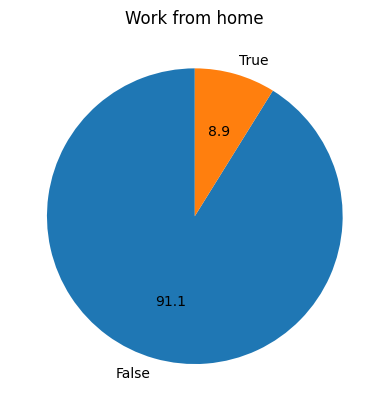

In [14]:
df["job_work_from_home"].value_counts().plot(kind="pie", startangle=90, autopct="%1.1f")
plt.title("Work from home")
plt.ylabel("")

Text(0.5, 1.0, 'Job count by title')

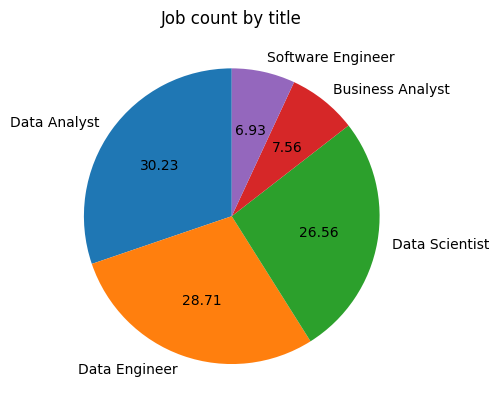

In [16]:
df["job_title_short"].value_counts().head(5).plot(kind="pie", startangle=90, autopct="%1.2f")
plt.title("Job title")
plt.ylabel("")
plt.title("Job count by title")

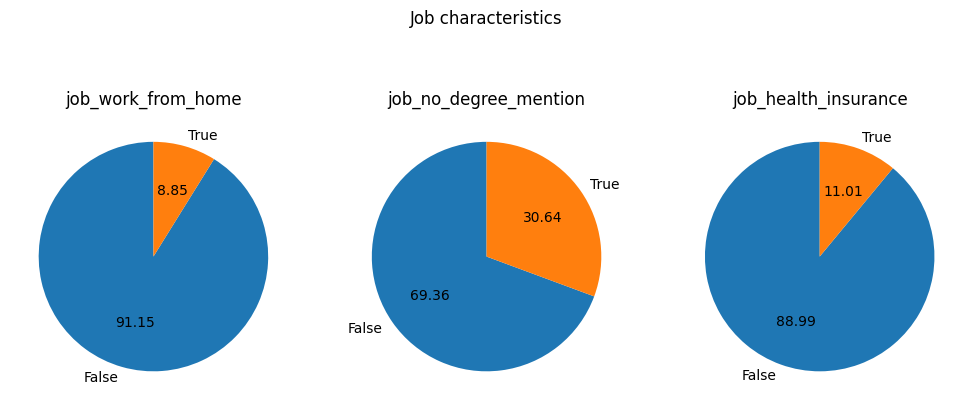

In [30]:
fig, ax = plt.subplots(1,3)

col_list = ["job_work_from_home", "job_no_degree_mention", "job_health_insurance"]

for elem in col_list:
  df[elem].value_counts().plot(
      title= elem,
      kind="pie",
      startangle=90,
      autopct="%1.2f",
      ylabel="",
      ax=ax[col_list.index(elem)])

fig.suptitle("Job characteristics")
fig.tight_layout()
fig.set_figwidth(10)